# TimesNet Strong-Backbone Confirmatory EPI Experiment

This section implements robustness and reliability checks for predictive utility and functional reliance under the fixed protocols reported in the paper.


In [1]:
from pathlib import Path
from types import SimpleNamespace

import gc
import importlib
import itertools
import random
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore")

SEED = 2026
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEQ_LEN = 96
LABEL_LEN = 48

CONDITIONS = [
    ("Electricity", 192),
    ("Solar", 720),
    ("ETTh1", 720),
]

N_SPLITS = 50
N_TEMPORAL_BLOCKS = 4
RANK_K = 5

# Conservative inference batching for TimesNet.
BASE_BATCH = {
    "Electricity": 8,
    "Solar": 8,
    "ETTh1": 32,
}

DONOR_CHUNK = {
    "Electricity": 4,
    "Solar": 4,
    "ETTh1": 8,
}

PROJECT_ROOT = Path("/data/code/2026_08")

PHASE1_ROOT = PROJECT_ROOT / "results_external_baselines_phase1_direct"

ITR_EPI_ROOT = (
    PROJECT_ROOT
    / "results_expected_permutation_importance_reliability"
)

ITR_EPI_PAIR_FILE = (
    ITR_EPI_ROOT
    / "expected_permutation_pair_scores.csv"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "results_timesnet_strong_backbone_epi"
)

CACHE_DIR = OUTPUT_DIR / "source_delta_cache"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

print("Phase-1 root:", PHASE1_ROOT)
print("iTransformer EPI root:", ITR_EPI_ROOT)
print("Output:", OUTPUT_DIR)

PyTorch: 2.4.1+cu121
Device: cuda
GPU: NVIDIA A100-SXM4-80GB
Phase-1 root: /data/code/2026_08/results_external_baselines_phase1_direct
iTransformer EPI root: /data/code/2026_08/results_expected_permutation_importance_reliability
Output: /data/code/2026_08/results_timesnet_strong_backbone_epi


## 1. Determinism and ranking metrics

In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

def safe_spearman(a, b):
    d = (
        pd.DataFrame({"a": a, "b": b})
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if len(d) < 3:
        return np.nan

    if d["a"].nunique() < 2 or d["b"].nunique() < 2:
        return np.nan

    return float(
        d.corr(method="spearman").iloc[0, 1]
    )

def topk_set(scores, ids, k):
    scores = np.asarray(scores, dtype=np.float64)
    ids = np.asarray(ids, dtype=np.int64)

    order = np.argsort(scores)[::-1][:k]

    return set(ids[order].tolist())

def topk_jaccard(a, b, ids, k):
    A = topk_set(a, ids, k)
    B = topk_set(b, ids, k)

    return len(A & B) / max(1, len(A | B))

## 2. Reuse the exact iTransformer EPI experiment protocol

In [3]:
if not ITR_EPI_PAIR_FILE.exists():
    raise FileNotFoundError(
        f"Missing prior EPI result:\n{ITR_EPI_PAIR_FILE}\n\n"
        "Run Expected_Permutation_Importance_Reliability_ICLR27.ipynb first."
    )

previous = pd.read_csv(ITR_EPI_PAIR_FILE)

required_columns = [
    "dataset",
    "pred_len",
    "target_channel",
    "source_channel",
    "pool_tag",

    "P_endpoint_mse_%",
    "P_full_mse_%",
    "P_full_mae_%",

    "I_Ridge_endpoint_mse_%",
    "I_Ridge_full_mse_%",
    "I_Ridge_full_mae_%",

    "I_MLP_endpoint_mse_%",
    "I_MLP_full_mse_%",
    "I_MLP_full_mae_%",

    "EPI_endpoint_mse_%",
    "EPI_full_mse_%",
    "EPI_full_mae_%",
]

missing = [
    c
    for c in required_columns
    if c not in previous.columns
]

if missing:
    raise RuntimeError(
        f"Prior EPI CSV is missing columns: {missing}"
    )

wanted = set(CONDITIONS)

previous = previous[
    previous.apply(
        lambda r: (
            r["dataset"],
            int(r["pred_len"]),
        )
        in
        wanted,
        axis=1,
    )
].copy()

print("Matched prior pair rows:", len(previous))

display(
    previous[
        [
            "dataset",
            "pred_len",
            "target_channel",
            "source_channel",
            "pool_tag",
        ]
    ].head(20)
)

Matched prior pair rows: 393


,dataset,pred_len,target_channel,source_channel,pool_tag
0,Electricity,192,0,46,base
1,Electricity,192,0,123,base
2,Electricity,192,0,99,base
3,Electricity,192,0,270,base
4,Electricity,192,0,127,base
5,Electricity,192,0,128,base
6,Electricity,192,0,115,base
7,Electricity,192,0,130,base
8,Electricity,192,0,219,base
9,Electricity,192,0,96,base


## 3. Locate Time-Series-Library and define exact Phase-1 TimesNet config

In [4]:
TSLIB_CANDIDATES = [
    Path("/data/Time-Series-Library"),
    Path("/data/Time-Series-Library_v2"),
    Path("/data/Time-Series-Library"),
]

TSL_ROOT = next(
    (
        p.resolve()
        for p in TSLIB_CANDIDATES
        if (p / "models" / "TimesNet.py").exists()
    ),
    None,
)

if TSL_ROOT is None:
    raise FileNotFoundError(
        "Time-Series-Library with models/TimesNet.py not found."
    )

if str(TSL_ROOT) not in sys.path:
    sys.path.insert(0, str(TSL_ROOT))

TimesNet_module = importlib.import_module("models.TimesNet")

# Exact Phase-1 ModelOnly v5 TimesNet settings.
TIMESNET_CFG = {
    "learning_rate": 1e-4,
    "batch_size": 32,
    "e_layers": 2,
    "d_layers": 1,
    "d_model": 32,
    "d_ff": 64,
    "n_heads": 8,
    "top_k": 5,
    "num_kernels": 6,
    "factor": 3,
    "dropout": 0.1,
}

DATASET_SPECS = {
    "Electricity": {
        "channels": 321,
        "freq": "h",
        "data": "custom",
        "target": "OT",
    },
    "Solar": {
        "channels": 137,
        "freq": "h",
        "data": "Solar",
        "target": "OT",
    },
    "ETTh1": {
        "channels": 7,
        "freq": "h",
        "data": "ETTh1",
        "target": "OT",
    },
}

print("TSLib:", TSL_ROOT)
print("TimesNet config:", TIMESNET_CFG)

TSLib: /data/Time-Series-Library
TimesNet config: {'learning_rate': 0.0001, 'batch_size': 32, 'e_layers': 2, 'd_layers': 1, 'd_model': 32, 'd_ff': 64, 'n_heads': 8, 'top_k': 5, 'num_kernels': 6, 'factor': 3, 'dropout': 0.1}


## 4. Dataset paths and identical normalization

In [5]:
DATASET_CANDIDATES = {
    "Electricity": [
        "/data/dataset/electricity/electricity.csv",
        "/data/dataset/ECL/electricity.csv",
        "/data/dataset/electricity.csv",
    ],
    "Solar": [
        "/data/dataset/solar/solar_AL.txt",
        "/data/dataset/Solar/solar_AL.txt",
        "/data/dataset/solar_AL.txt",
    ],
    "ETTh1": [
        "/data/dataset/ETT-small/ETTh1.csv",
        "/data/dataset/ETTh1.csv",
    ],
}

def resolve_path(candidates):
    for p in candidates:
        p = Path(p)

        if p.exists():
            return p.resolve()

    return None

DATASET_FILES = {}

for d, candidates in DATASET_CANDIDATES.items():
    p = resolve_path(candidates)

    if p is None:
        raise FileNotFoundError(
            f"{d}: dataset file not found."
        )

    DATASET_FILES[d] = p

    print(f"{d:12s} -> {p}")

def load_numeric_series(dataset_name, path):
    path = Path(path)

    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)

        date_col = None

        for candidate in [
            "date",
            "datetime",
            "timestamp",
            "time",
        ]:
            if candidate in df.columns:
                date_col = candidate
                break

        if date_col is None:
            first = df.columns[0]

            if not pd.api.types.is_numeric_dtype(
                df[first]
            ):
                date_col = first

        if date_col is not None:
            df = df.drop(columns=[date_col])

        df = df.select_dtypes(include=[np.number])

        x = df.to_numpy(dtype=np.float32)

    else:
        try:
            x = np.loadtxt(
                path,
                delimiter=",",
                dtype=np.float32,
            )

        except Exception:
            x = np.loadtxt(
                path,
                dtype=np.float32,
            )

        if x.ndim == 1:
            x = x[:, None]

    if x.ndim != 2:
        raise ValueError(
            f"{dataset_name}: unexpected shape {x.shape}"
        )

    if not np.isfinite(x).all():
        raise ValueError(
            f"{dataset_name}: non-finite data"
        )

    return x

def split_boundaries(dataset_name, T):
    if dataset_name == "ETTh1":
        train_end = 12 * 30 * 24
        val_end = train_end + 4 * 30 * 24
        test_end = val_end + 4 * 30 * 24

        return (
            min(train_end, T),
            min(val_end, T),
            min(test_end, T),
        )

    return (
        int(0.70 * T),
        int(0.80 * T),
        T,
    )

def load_and_normalize(dataset_name):
    raw = load_numeric_series(
        dataset_name,
        DATASET_FILES[dataset_name],
    )

    T, C = raw.shape

    train_end, val_end, test_end = split_boundaries(
        dataset_name,
        T,
    )

    train = raw[:train_end]

    mean = train.mean(axis=0, keepdims=True)
    std = np.maximum(
        train.std(axis=0, keepdims=True),
        1e-6,
    )

    x = (raw - mean) / std

    return x.astype(np.float32), {
        "T": T,
        "C": C,
        "train_end": train_end,
        "val_end": val_end,
        "test_end": test_end,
    }

def make_XY_from_origins(x, origins, H):
    X = np.stack(
        [
            x[t-SEQ_LEN:t]
            for t in origins
        ],
        axis=0,
    ).astype(np.float32)

    Y = np.stack(
        [
            x[t:t+H]
            for t in origins
        ],
        axis=0,
    ).astype(np.float32)

    return X, Y

Electricity  -> /data/dataset/electricity/electricity.csv
Solar        -> /data/dataset/solar/solar_AL.txt
ETTh1        -> /data/dataset/ETT-small/ETTh1.csv


## 5. Exact Phase-1 TimesNet model and checkpoint

In [6]:
def build_timesnet_args(dataset_name, H):
    spec = DATASET_SPECS[dataset_name]
    cfg = TIMESNET_CFG

    data_file = DATASET_FILES[dataset_name]

    return SimpleNamespace(
        task_name="long_term_forecast",
        model="TimesNet",

        data=spec["data"],
        root_path=str(data_file.parent) + "/",
        data_path=data_file.name,
        features="M",
        target=spec["target"],
        freq=spec["freq"],

        seq_len=SEQ_LEN,
        label_len=LABEL_LEN,
        pred_len=H,
        seasonal_patterns="Monthly",
        inverse=False,

        enc_in=spec["channels"],
        dec_in=spec["channels"],
        c_out=spec["channels"],

        e_layers=cfg["e_layers"],
        d_layers=cfg["d_layers"],
        factor=cfg["factor"],
        d_model=cfg["d_model"],
        n_heads=cfg["n_heads"],
        d_ff=cfg["d_ff"],
        moving_avg=25,
        distil=True,
        dropout=cfg["dropout"],
        embed="timeF",
        activation="gelu",
        output_attention=False,

        top_k=cfg["top_k"],
        num_kernels=cfg["num_kernels"],

        # fields used by the TSLib fork
        class_strategy="projection",
        use_norm=1,
        augmentation_ratio=0,
        channel_independence=0,
    )

def timesnet_checkpoint(dataset_name, H):
    return (
        PHASE1_ROOT
        / "TimesNet"
        / dataset_name
        / f"H{H}"
        / "best_model.pt"
    )

def timesnet_result_file(dataset_name, H):
    return (
        PHASE1_ROOT
        / "TimesNet"
        / dataset_name
        / f"H{H}"
        / "result.csv"
    )

def load_timesnet(dataset_name, H):
    args = build_timesnet_args(
        dataset_name,
        H,
    )

    model = (
        TimesNet_module
        .Model(args)
        .float()
        .to(DEVICE)
    )

    ckpt = timesnet_checkpoint(
        dataset_name,
        H,
    )

    if not ckpt.exists():
        raise FileNotFoundError(
            f"Phase-1 TimesNet checkpoint not found: {ckpt}"
        )

    state = torch.load(
        ckpt,
        map_location="cpu",
    )

    model.load_state_dict(
        state,
        strict=True,
    )

    model.eval()

    return model, args

## 6. Reuse exact iTransformer EPI origins and donor mappings

In [7]:
def load_condition_protocol(dataset_name, H):
    meta_path = (
        ITR_EPI_ROOT
        / f"{dataset_name}_H{H}_meta.npz"
    )

    if not meta_path.exists():
        raise FileNotFoundError(
            f"Missing prior EPI protocol file: {meta_path}"
        )

    z = np.load(meta_path)

    origins = z["origins"].astype(np.int64)
    targets = z["targets"].astype(np.int64)
    sources = z["sources"].astype(np.int64)
    shifts = z["shifts"].astype(np.int64)
    maps = z["maps"].astype(np.int64)

    if maps.shape[1] != len(origins):
        raise RuntimeError(
            f"Donor-map length mismatch: {maps.shape} vs {len(origins)} origins"
        )

    pair_df = previous[
        (
            previous["dataset"]
            ==
            dataset_name
        )
        &
        (
            previous["pred_len"].astype(int)
            ==
            int(H)
        )
    ].copy()

    return {
        "origins": origins,
        "targets": targets,
        "sources": sources,
        "shifts": shifts,
        "maps": maps,
        "pair_df": pair_df,
    }

for dataset_name, H in CONDITIONS:
    p = load_condition_protocol(
        dataset_name,
        H,
    )

    print(
        f"{dataset_name} H={H}: "
        f"windows={len(p['origins'])}, "
        f"targets={len(p['targets'])}, "
        f"sources={len(p['sources'])}, "
        f"donors={len(p['shifts'])}, "
        f"pairs={len(p['pair_df'])}"
    )

Electricity H=192: windows=512, targets=6, sources=132, donors=16, pairs=173
Solar H=720: windows=512, targets=6, sources=94, donors=16, pairs=178
ETTh1 H=720: windows=512, targets=7, sources=7, donors=16, pairs=42


## 7. TimesNet forward pass exactly matching Phase-1 ModelOnly

In [8]:
@torch.inference_mode()
def timesnet_forward(model, x, H):
    B, _, C = x.shape

    # Phase-1 used label_len=48 followed by zeros for the prediction horizon.
    # TimesNet consumes x_enc and decoder input in the same generic TSLib call.
    dec_hist = x[:, -LABEL_LEN:, :]

    dec_zeros = torch.zeros(
        B,
        H,
        C,
        dtype=x.dtype,
        device=x.device,
    )

    dec_inp = torch.cat(
        [
            dec_hist,
            dec_zeros,
        ],
        dim=1,
    )

    out = model(
        x,
        None,
        dec_inp,
        None,
    )

    if isinstance(out, tuple):
        out = out[0]

    return out[:, -H:, :]

def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
    )

## 8. Checkpoint and forward pre-flight

In [9]:
for dataset_name, H in CONDITIONS:
    model, args = load_timesnet(
        dataset_name,
        H,
    )

    protocol = load_condition_protocol(
        dataset_name,
        H,
    )

    x_norm, meta = load_and_normalize(
        dataset_name
    )

    if meta["C"] != DATASET_SPECS[dataset_name]["channels"]:
        raise RuntimeError(
            f"{dataset_name}: C mismatch "
            f"{meta['C']} vs {DATASET_SPECS[dataset_name]['channels']}"
        )

    X, Y = make_XY_from_origins(
        x_norm,
        protocol["origins"][:2],
        H,
    )

    xb = torch.from_numpy(
        X
    ).float().to(DEVICE)

    with torch.no_grad():
        pred = timesnet_forward(
            model,
            xb,
            H,
        )

    print(
        f"{dataset_name} H={H} | "
        f"params={count_parameters(model):,} | "
        f"pred={tuple(pred.shape)} | "
        f"finite={bool(torch.isfinite(pred).all())}"
    )

    result_path = timesnet_result_file(
        dataset_name,
        H,
    )

    if result_path.exists():
        r = pd.read_csv(result_path)

        if len(r) == 1:
            print(
                "  Phase-1:",
                f"test MSE={float(r.iloc[0]['test_mse']):.6f}",
                f"MAE={float(r.iloc[0]['test_mae']):.6f}",
            )

    assert pred.shape == (
        len(X),
        H,
        meta["C"],
    )

    assert torch.isfinite(pred).all()

    del model, xb, pred, X, Y

    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print("Pre-flight: PASSED")

Electricity H=192 | params=2,413,601 | pred=(2, 192, 321) | finite=True
  Phase-1: test MSE=0.195382 MAE=0.297641
Solar H=720 | params=2,441,081 | pred=(2, 720, 137) | finite=True
  Phase-1: test MSE=0.307866 MAE=0.319142
ETTh1 H=720 | params=2,424,311 | pred=(2, 720, 7) | finite=True
  Phase-1: test MSE=0.542674 MAE=0.507804
Pre-flight: PASSED


## 9. Clean TimesNet per-window losses

In [10]:
@torch.inference_mode()
def clean_losses(
    model,
    X,
    Y,
    targets,
    H,
    batch_size,
):
    N = len(X)
    Tn = len(targets)

    output = {
        "endpoint_mse": np.zeros(
            (N, Tn),
            dtype=np.float32,
        ),
        "full_mse": np.zeros(
            (N, Tn),
            dtype=np.float32,
        ),
        "full_mae": np.zeros(
            (N, Tn),
            dtype=np.float32,
        ),
    }

    for start in range(
        0,
        N,
        batch_size,
    ):
        end = min(
            start + batch_size,
            N,
        )

        xb = torch.from_numpy(
            X[start:end]
        ).float().to(DEVICE)

        yb = torch.from_numpy(
            Y[start:end]
        ).float().to(DEVICE)

        pred = timesnet_forward(
            model,
            xb,
            H,
        )

        err = (
            pred[:, :, targets]
            -
            yb[:, :, targets]
        )

        output["endpoint_mse"][start:end] = (
            err[:, -1, :]
            .square()
            .cpu()
            .numpy()
        )

        output["full_mse"][start:end] = (
            err
            .square()
            .mean(dim=1)
            .cpu()
            .numpy()
        )

        output["full_mae"][start:end] = (
            err
            .abs()
            .mean(dim=1)
            .cpu()
            .numpy()
        )

    return output

## 10. Source intervention cache — same 16 donors as iTransformer

In [11]:
def source_cache_path(
    dataset_name,
    H,
    source_idx,
):
    d = (
        CACHE_DIR
        / f"{dataset_name}_H{H}"
    )

    d.mkdir(
        parents=True,
        exist_ok=True,
    )

    return (
        d
        / f"source_{int(source_idx):04d}.npz"
    )

@torch.inference_mode()
def compute_source_cache(
    model,
    dataset_name,
    H,
    source_idx,
    X,
    Y,
    targets,
    donor_maps,
    clean,
    batch_size,
    donor_chunk,
):
    path = source_cache_path(
        dataset_name,
        H,
        source_idx,
    )

    if path.exists():
        return True

    R, N = donor_maps.shape
    Tn = len(targets)

    delta_endpoint = np.zeros(
        (R, N, Tn),
        dtype=np.float32,
    )

    delta_full_mse = np.zeros(
        (R, N, Tn),
        dtype=np.float32,
    )

    delta_full_mae = np.zeros(
        (R, N, Tn),
        dtype=np.float32,
    )

    for start in range(
        0,
        N,
        batch_size,
    ):
        end = min(
            start + batch_size,
            N,
        )

        B = end - start
        base_x = X[start:end]

        yb = torch.from_numpy(
            Y[start:end]
        ).float().to(DEVICE)

        global_idx = np.arange(
            start,
            end,
            dtype=np.int64,
        )

        for r_start in range(
            0,
            R,
            donor_chunk,
        ):
            r_idx = np.arange(
                r_start,
                min(
                    r_start + donor_chunk,
                    R,
                ),
                dtype=np.int64,
            )

            Q = len(r_idx)

            aug = np.broadcast_to(
                base_x[None],
                (
                    Q,
                    B,
                    base_x.shape[1],
                    base_x.shape[2],
                ),
            ).copy()

            for q, r in enumerate(
                r_idx
            ):
                donor_idx = donor_maps[
                    r,
                    global_idx,
                ]

                aug[
                    q,
                    :,
                    :,
                    source_idx,
                ] = X[
                    donor_idx,
                    :,
                    source_idx,
                ]

            aug_t = torch.from_numpy(
                aug.reshape(
                    Q * B,
                    aug.shape[2],
                    aug.shape[3],
                )
            ).float().to(DEVICE)

            pred = timesnet_forward(
                model,
                aug_t,
                H,
            )

            pred = pred.reshape(
                Q,
                B,
                H,
                pred.shape[-1],
            )

            truth = yb[
                None,
                :,
                :,
                targets,
            ]

            err = (
                pred[:, :, :, targets]
                -
                truth
            )

            pert_endpoint = (
                err[:, :, -1, :]
                .square()
                .cpu()
                .numpy()
            )

            pert_full_mse = (
                err
                .square()
                .mean(dim=2)
                .cpu()
                .numpy()
            )

            pert_full_mae = (
                err
                .abs()
                .mean(dim=2)
                .cpu()
                .numpy()
            )

            for q, r in enumerate(
                r_idx
            ):
                delta_endpoint[
                    r,
                    start:end,
                ] = (
                    pert_endpoint[q]
                    -
                    clean["endpoint_mse"][start:end]
                )

                delta_full_mse[
                    r,
                    start:end,
                ] = (
                    pert_full_mse[q]
                    -
                    clean["full_mse"][start:end]
                )

                delta_full_mae[
                    r,
                    start:end,
                ] = (
                    pert_full_mae[q]
                    -
                    clean["full_mae"][start:end]
                )

            del (
                aug,
                aug_t,
                pred,
                err,
                pert_endpoint,
                pert_full_mse,
                pert_full_mae,
            )

    np.savez_compressed(
        path,
        delta_endpoint_mse=delta_endpoint,
        delta_full_mse=delta_full_mse,
        delta_full_mae=delta_full_mae,
    )

    return False

## 11. Run TimesNet EPI caches with resume

In [12]:
def run_condition_cache(
    dataset_name,
    H,
):
    protocol = load_condition_protocol(
        dataset_name,
        H,
    )

    x_norm, meta = load_and_normalize(
        dataset_name
    )

    X, Y = make_XY_from_origins(
        x_norm,
        protocol["origins"],
        H,
    )

    model, args = load_timesnet(
        dataset_name,
        H,
    )

    clean_file = (
        OUTPUT_DIR
        / f"{dataset_name}_H{H}_clean.npz"
    )

    if clean_file.exists():
        z = np.load(clean_file)

        clean = {
            "endpoint_mse": z["endpoint_mse"],
            "full_mse": z["full_mse"],
            "full_mae": z["full_mae"],
        }

        print("Reusing clean losses.")

    else:
        clean = clean_losses(
            model,
            X,
            Y,
            protocol["targets"],
            H,
            BASE_BATCH[dataset_name],
        )

        np.savez_compressed(
            clean_file,
            **clean,
        )

    # Save exact copied protocol for reproducibility.
    np.savez_compressed(
        OUTPUT_DIR
        / f"{dataset_name}_H{H}_protocol.npz",
        origins=protocol["origins"],
        targets=protocol["targets"],
        sources=protocol["sources"],
        shifts=protocol["shifts"],
        maps=protocol["maps"],
    )

    reused = 0

    for q, source_idx in enumerate(
        protocol["sources"],
        start=1,
    ):
        was_reused = compute_source_cache(
            model=model,
            dataset_name=dataset_name,
            H=H,
            source_idx=int(source_idx),
            X=X,
            Y=Y,
            targets=protocol["targets"],
            donor_maps=protocol["maps"],
            clean=clean,
            batch_size=BASE_BATCH[dataset_name],
            donor_chunk=DONOR_CHUNK[dataset_name],
        )

        reused += int(was_reused)

        print(
            f"  source {q}/{len(protocol['sources'])}: "
            f"{int(source_idx)} "
            f"{'reused' if was_reused else 'computed'}"
        )

        gc.collect()

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    print(
        f"{dataset_name} H={H} complete | "
        f"reused {reused}/{len(protocol['sources'])}"
    )

    del model, X, Y

    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

# Smallest condition first.
run_condition_cache(
    "ETTh1",
    720,
)

print("ETTh1 pre-flight cache: COMPLETE")

  source 1/7: 0 computed
  source 2/7: 1 computed
  source 3/7: 2 computed
  source 4/7: 3 computed
  source 5/7: 4 computed
  source 6/7: 5 computed
  source 7/7: 6 computed
ETTh1 H=720 complete | reused 0/7
ETTh1 pre-flight cache: COMPLETE


In [13]:
for dataset_name, H in CONDITIONS:
    print("\n" + "=" * 100)
    print(f"TimesNet EPI | {dataset_name} H={H}")
    print("=" * 100)

    run_condition_cache(
        dataset_name,
        H,
    )

print("\nAll TimesNet source caches complete.")


TimesNet EPI | Electricity H=192
  source 1/132: 1 computed
  source 2/132: 8 computed
  source 3/132: 11 computed
  source 4/132: 13 computed
  source 5/132: 14 computed
  source 6/132: 23 computed
  source 7/132: 26 computed
  source 8/132: 29 computed
  source 9/132: 33 computed
  source 10/132: 34 computed
  source 11/132: 41 computed
  source 12/132: 42 computed
  source 13/132: 44 computed
  source 14/132: 46 computed
  source 15/132: 48 computed
  source 16/132: 51 computed
  source 17/132: 52 computed
  source 18/132: 55 computed
  source 19/132: 58 computed
  source 20/132: 63 computed
  source 21/132: 65 computed
  source 22/132: 68 computed
  source 23/132: 70 computed
  source 24/132: 71 computed
  source 25/132: 73 computed
  source 26/132: 77 computed
  source 27/132: 78 computed
  source 28/132: 83 computed
  source 29/132: 86 computed
  source 30/132: 87 computed
  source 31/132: 94 computed
  source 32/132: 96 computed
  source 33/132: 97 computed
  source 34/132: 98 

## 12. Assemble TimesNet EPI pair scores

In [14]:
METRICS = {
    "endpoint_mse": {
        "delta": "delta_endpoint_mse",
        "P": "P_endpoint_mse_%",
        "Ridge": "I_Ridge_endpoint_mse_%",
        "MLP": "I_MLP_endpoint_mse_%",
        "iTransformer": "EPI_endpoint_mse_%",
        "TimesNet": "EPI_TimesNet_endpoint_mse_%",
    },

    "full_mse": {
        "delta": "delta_full_mse",
        "P": "P_full_mse_%",
        "Ridge": "I_Ridge_full_mse_%",
        "MLP": "I_MLP_full_mse_%",
        "iTransformer": "EPI_full_mse_%",
        "TimesNet": "EPI_TimesNet_full_mse_%",
    },

    "full_mae": {
        "delta": "delta_full_mae",
        "P": "P_full_mae_%",
        "Ridge": "I_Ridge_full_mae_%",
        "MLP": "I_MLP_full_mae_%",
        "iTransformer": "EPI_full_mae_%",
        "TimesNet": "EPI_TimesNet_full_mae_%",
    },
}

def load_timesnet_arrays(
    dataset_name,
    H,
):
    proto = np.load(
        OUTPUT_DIR
        / f"{dataset_name}_H{H}_protocol.npz"
    )

    clean_z = np.load(
        OUTPUT_DIR
        / f"{dataset_name}_H{H}_clean.npz"
    )

    targets = proto["targets"].astype(np.int64)
    sources = proto["sources"].astype(np.int64)

    clean = {
        m: clean_z[m].astype(np.float32)
        for m in METRICS
    }

    delta = {}

    for metric, info in METRICS.items():
        blocks = []

        for source_idx in sources:
            z = np.load(
                source_cache_path(
                    dataset_name,
                    H,
                    int(source_idx),
                )
            )

            blocks.append(
                z[info["delta"]].astype(np.float32)
            )

        # [S,R,N,T] -> [R,N,T,S]
        delta[metric] = (
            np.stack(
                blocks,
                axis=0,
            )
            .transpose(
                1,
                2,
                3,
                0,
            )
        )

    return {
        "targets": targets,
        "sources": sources,
        "origins": proto["origins"].astype(np.int64),
        "shifts": proto["shifts"].astype(np.int64),
        "clean": clean,
        "delta": delta,
    }

def importance_from_subset(
    delta,
    clean,
    donors=None,
    windows=None,
):
    R, N, Tn, Sn = delta.shape

    if donors is None:
        donors = np.arange(R)

    if windows is None:
        windows = np.arange(N)

    donors = np.asarray(
        donors,
        dtype=np.int64,
    )

    windows = np.asarray(
        windows,
        dtype=np.int64,
    )

    d = delta[
        np.ix_(
            donors,
            windows,
            np.arange(Tn),
            np.arange(Sn),
        )
    ]

    mean_delta = d.mean(
        axis=(0, 1)
    )

    mean_clean = clean[
        windows
    ].mean(
        axis=0
    )

    return (
        100.0
        *
        mean_delta
        /
        np.maximum(
            mean_clean[:, None],
            1e-12,
        )
    )

timesnet_arrays = {}
pair_frames = []

for dataset_name, H in CONDITIONS:
    arrays = load_timesnet_arrays(
        dataset_name,
        H,
    )

    timesnet_arrays[
        (dataset_name, H)
    ] = arrays

    p = previous[
        (
            previous["dataset"]
            ==
            dataset_name
        )
        &
        (
            previous["pred_len"].astype(int)
            ==
            int(H)
        )
    ].copy()

    target_pos = {
        int(v): q
        for q, v in enumerate(
            arrays["targets"]
        )
    }

    source_pos = {
        int(v): q
        for q, v in enumerate(
            arrays["sources"]
        )
    }

    epi = {
        metric: importance_from_subset(
            arrays["delta"][metric],
            arrays["clean"][metric],
        )
        for metric in METRICS
    }

    rows = []

    for _, row in p.iterrows():
        rr = row.to_dict()

        tq = target_pos[
            int(row["target_channel"])
        ]

        sq = source_pos[
            int(row["source_channel"])
        ]

        for metric, info in METRICS.items():
            rr[
                info["TimesNet"]
            ] = float(
                epi[metric][tq, sq]
            )

        rows.append(rr)

    pair_frames.append(
        pd.DataFrame(rows)
    )

timesnet_pairs = pd.concat(
    pair_frames,
    ignore_index=True,
)

timesnet_pairs.to_csv(
    OUTPUT_DIR
    / "timesnet_epi_pair_scores.csv",
    index=False,
)

print("TimesNet EPI pair rows:", len(timesnet_pairs))

display(
    timesnet_pairs.head(20).round(4)
)

TimesNet EPI pair rows: 393


,dataset,pred_len,target_channel,source_channel,pool_tag,raw_abs_corr,P_endpoint_mse_%,P_full_mse_%,P_full_mae_%,I_iTransformer_endpoint_mse_%,...,I_Ridge_full_mae_%,I_MLP_endpoint_mse_%,I_MLP_full_mse_%,I_MLP_full_mae_%,EPI_endpoint_mse_%,EPI_full_mse_%,EPI_full_mae_%,EPI_TimesNet_endpoint_mse_%,EPI_TimesNet_full_mse_%,EPI_TimesNet_full_mae_%
0,Electricity,192,0,46,base,0.2108,-7.0641,-8.1682,-10.8208,-0.2519,...,2.1650,4.0924,4.6619,2.7684,-0.2757,-0.2792,-0.1018,0.0888,0.0005,-0.0007
1,Electricity,192,0,123,base,0.2098,2.0731,0.4002,-2.1247,-0.2353,...,-2.8789,2.6274,2.4981,2.4436,-0.2203,-0.0592,-0.1479,0.0258,-0.1231,-0.0460
2,Electricity,192,0,99,base,0.1871,0.1400,0.0073,-0.4590,-0.2365,...,-1.3240,1.0386,0.9451,1.0380,-0.1476,0.0415,-0.0710,-0.3091,-0.1474,0.0030
3,Electricity,192,0,270,base,0.1800,-5.9889,-9.9914,-7.3117,-0.0147,...,5.5935,0.3260,1.1033,1.7668,-0.1423,-0.1500,-0.1114,-0.4353,-0.1516,-0.0902
4,Electricity,192,0,127,base,0.1726,0.4396,-0.2725,-0.3610,-0.2163,...,0.6092,-0.1438,-0.4685,1.7123,-0.2123,-0.0517,-0.0846,-0.6820,-0.2978,-0.1362
5,Electricity,192,0,128,base,0.1599,-3.6407,-4.0292,-3.5608,-0.2075,...,0.6190,-1.5579,0.0183,0.7137,-0.2494,-0.1822,-0.1336,-0.6212,-0.2567,-0.0346
6,Electricity,192,0,115,base,0.1580,-4.8527,-3.6146,-4.1619,-0.1362,...,-5.7448,-7.1603,-12.2476,-5.2323,-0.2956,-0.1317,-0.1206,-0.2946,-0.1229,0.0502
7,Electricity,192,0,130,base,0.1531,0.2202,-0.1331,-0.9530,-0.1584,...,0.3293,-0.1259,0.1511,0.2073,-0.1586,-0.0703,-0.1072,0.2357,0.1532,0.0009
8,Electricity,192,0,219,base,0.0893,1.6380,1.2434,-1.6600,-0.0562,...,-1.3124,-1.0123,-0.4759,-0.5393,-0.1090,-0.1155,-0.0780,-0.0024,-0.0026,-0.0364
9,Electricity,192,0,96,base,0.0173,0.9455,-0.2397,-1.0091,-0.3080,...,4.9876,6.7810,5.6664,4.1116,-0.2543,-0.1501,-0.0835,0.0608,0.0291,-0.0266


## 13. TimesNet EPI reliability

In [15]:
def valid_source_mask(
    pair_df,
    target,
    sources,
):
    valid = set(
        pair_df[
            pair_df["target_channel"].astype(int)
            ==
            int(target)
        ]["source_channel"]
        .astype(int)
        .tolist()
    )

    return np.asarray(
        [
            int(s) in valid
            for s in sources
        ],
        dtype=bool,
    )

donor_rows = []
window_rows = []
temporal_rows = []

for dataset_name, H in CONDITIONS:
    a = timesnet_arrays[
        (dataset_name, H)
    ]

    p = timesnet_pairs[
        (
            timesnet_pairs["dataset"]
            ==
            dataset_name
        )
        &
        (
            timesnet_pairs["pred_len"].astype(int)
            ==
            int(H)
        )
    ]

    R = len(a["shifts"])
    N = len(a["origins"])

    rng_d = np.random.default_rng(
        SEED + H * 101 + 37
    )

    rng_w = np.random.default_rng(
        SEED + H * 211 + 73
    )

    temporal_blocks = [
        np.asarray(b, dtype=np.int64)
        for b in np.array_split(
            np.arange(N),
            N_TEMPORAL_BLOCKS,
        )
    ]

    for metric in METRICS:
        d = a["delta"][metric]
        c = a["clean"][metric]

        for tq, target in enumerate(
            a["targets"]
        ):
            mask = valid_source_mask(
                p,
                int(target),
                a["sources"],
            )

            if mask.sum() < 3:
                continue

            # Donor 8-vs-8
            rhos = []

            for _ in range(N_SPLITS):
                perm = rng_d.permutation(R)

                A = perm[:R//2]
                B = perm[R//2:]

                IA = importance_from_subset(
                    d,
                    c,
                    donors=A,
                )[tq, mask]

                IB = importance_from_subset(
                    d,
                    c,
                    donors=B,
                )[tq, mask]

                rho = safe_spearman(
                    IA,
                    IB,
                )

                if np.isfinite(rho):
                    rhos.append(rho)

            donor_rows.append({
                "dataset": dataset_name,
                "pred_len": int(H),
                "target_channel": int(target),
                "metric": metric,
                "median_rho": (
                    float(np.median(rhos))
                    if rhos
                    else np.nan
                ),
                "mean_rho": (
                    float(np.mean(rhos))
                    if rhos
                    else np.nan
                ),
            })

            # Random-window split-half
            rhos = []

            for _ in range(N_SPLITS):
                perm = rng_w.permutation(N)

                A = perm[:N//2]
                B = perm[N//2:]

                IA = importance_from_subset(
                    d,
                    c,
                    windows=A,
                )[tq, mask]

                IB = importance_from_subset(
                    d,
                    c,
                    windows=B,
                )[tq, mask]

                rho = safe_spearman(
                    IA,
                    IB,
                )

                if np.isfinite(rho):
                    rhos.append(rho)

            window_rows.append({
                "dataset": dataset_name,
                "pred_len": int(H),
                "target_channel": int(target),
                "metric": metric,
                "median_rho": (
                    float(np.median(rhos))
                    if rhos
                    else np.nan
                ),
                "mean_rho": (
                    float(np.mean(rhos))
                    if rhos
                    else np.nan
                ),
            })

            # Contiguous temporal blocks
            block_scores = [
                importance_from_subset(
                    d,
                    c,
                    windows=b,
                )[tq, mask]
                for b in temporal_blocks
            ]

            rhos = []

            for i, j in itertools.combinations(
                range(len(block_scores)),
                2,
            ):
                rho = safe_spearman(
                    block_scores[i],
                    block_scores[j],
                )

                if np.isfinite(rho):
                    rhos.append(rho)

            temporal_rows.append({
                "dataset": dataset_name,
                "pred_len": int(H),
                "target_channel": int(target),
                "metric": metric,
                "mean_block_rho": (
                    float(np.mean(rhos))
                    if rhos
                    else np.nan
                ),
                "median_block_rho": (
                    float(np.median(rhos))
                    if rhos
                    else np.nan
                ),
            })

donor_target = pd.DataFrame(donor_rows)
window_target = pd.DataFrame(window_rows)
temporal_target = pd.DataFrame(temporal_rows)

def reliability_summary(
    df,
    value_col,
):
    return (
        df
        .groupby(
            [
                "dataset",
                "pred_len",
                "metric",
            ],
            as_index=False,
        )
        .agg(
            targets=(
                "target_channel",
                "size",
            ),
            median_rho=(
                value_col,
                "median",
            ),
            mean_rho=(
                value_col,
                "mean",
            ),
        )
    )

donor_summary = reliability_summary(
    donor_target,
    "median_rho",
)

window_summary = reliability_summary(
    window_target,
    "median_rho",
)

temporal_summary = reliability_summary(
    temporal_target,
    "mean_block_rho",
)

donor_target.to_csv(
    OUTPUT_DIR
    / "timesnet_donor_reliability_target.csv",
    index=False,
)

window_target.to_csv(
    OUTPUT_DIR
    / "timesnet_window_reliability_target.csv",
    index=False,
)

temporal_target.to_csv(
    OUTPUT_DIR
    / "timesnet_temporal_stability_target.csv",
    index=False,
)

donor_summary.to_csv(
    OUTPUT_DIR
    / "timesnet_donor_reliability_summary.csv",
    index=False,
)

window_summary.to_csv(
    OUTPUT_DIR
    / "timesnet_window_reliability_summary.csv",
    index=False,
)

temporal_summary.to_csv(
    OUTPUT_DIR
    / "timesnet_temporal_stability_summary.csv",
    index=False,
)

print("TimesNet donor reliability")
display(donor_summary.round(3))

print("TimesNet random-window reliability")
display(window_summary.round(3))

print("TimesNet temporal-block stability")
display(temporal_summary.round(3))

TimesNet donor reliability


,dataset,pred_len,metric,targets,median_rho,mean_rho
0,ETTh1,720,endpoint_mse,7,0.943,0.804
1,ETTh1,720,full_mae,7,0.943,0.935
2,ETTh1,720,full_mse,7,0.943,0.898
3,Electricity,192,endpoint_mse,6,0.914,0.903
4,Electricity,192,full_mae,6,0.934,0.900
5,Electricity,192,full_mse,6,0.927,0.923
6,Solar,720,endpoint_mse,6,0.977,0.977
7,Solar,720,full_mae,6,0.977,0.976
8,Solar,720,full_mse,6,0.983,0.981


TimesNet random-window reliability


,dataset,pred_len,metric,targets,median_rho,mean_rho
0,ETTh1,720,endpoint_mse,7,0.714,0.710
1,ETTh1,720,full_mae,7,1.000,0.976
2,ETTh1,720,full_mse,7,1.000,0.976
3,Electricity,192,endpoint_mse,6,0.783,0.787
4,Electricity,192,full_mae,6,0.935,0.910
5,Electricity,192,full_mse,6,0.943,0.940
6,Solar,720,endpoint_mse,6,0.970,0.972
7,Solar,720,full_mae,6,0.981,0.979
8,Solar,720,full_mse,6,0.988,0.986


TimesNet temporal-block stability


,dataset,pred_len,metric,targets,median_rho,mean_rho
0,ETTh1,720,endpoint_mse,7,0.190,0.252
1,ETTh1,720,full_mae,7,0.552,0.459
2,ETTh1,720,full_mse,7,0.333,0.382
3,Electricity,192,endpoint_mse,6,-0.053,-0.003
4,Electricity,192,full_mae,6,0.085,0.150
5,Electricity,192,full_mse,6,0.033,0.085
6,Solar,720,endpoint_mse,6,0.910,0.924
7,Solar,720,full_mae,6,0.890,0.855
8,Solar,720,full_mse,6,0.945,0.939


## 14. \(P\) vs TimesNet and iTransformer vs TimesNet

In [16]:
alignment_rows = []

for (
    dataset,
    H,
    target,
), sub_all in timesnet_pairs.groupby(
    [
        "dataset",
        "pred_len",
        "target_channel",
    ]
):
    for pool_name, sub in [
        (
            "BaseOnly",
            sub_all[
                sub_all["pool_tag"]
                ==
                "base"
            ],
        ),
        (
            "Extended",
            sub_all,
        ),
    ]:
        if len(sub) < 3:
            continue

        ids = sub[
            "source_channel"
        ].to_numpy()

        k = min(
            RANK_K,
            len(sub),
        )

        for metric, info in METRICS.items():
            alignment_rows.append({
                "dataset": dataset,
                "pred_len": int(H),
                "target_channel": int(target),
                "pool": pool_name,
                "metric": metric,

                "rho_P_TimesNet": safe_spearman(
                    sub[info["P"]],
                    sub[info["TimesNet"]],
                ),

                "rho_iTransformer_TimesNet": safe_spearman(
                    sub[info["iTransformer"]],
                    sub[info["TimesNet"]],
                ),

                "jaccard_P_TimesNet": topk_jaccard(
                    sub[info["P"]],
                    sub[info["TimesNet"]],
                    ids,
                    k,
                ),

                "jaccard_iTransformer_TimesNet": topk_jaccard(
                    sub[info["iTransformer"]],
                    sub[info["TimesNet"]],
                    ids,
                    k,
                ),
            })

alignment_target = pd.DataFrame(
    alignment_rows
)

alignment_summary = (
    alignment_target
    .groupby(
        [
            "pool",
            "metric",
        ],
        as_index=False,
    )
    .agg(
        targets=(
            "target_channel",
            "size",
        ),
        median_rho_P_TimesNet=(
            "rho_P_TimesNet",
            "median",
        ),
        mean_rho_P_TimesNet=(
            "rho_P_TimesNet",
            "mean",
        ),
        median_rho_iTransformer_TimesNet=(
            "rho_iTransformer_TimesNet",
            "median",
        ),
        mean_rho_iTransformer_TimesNet=(
            "rho_iTransformer_TimesNet",
            "mean",
        ),
        mean_jaccard_P_TimesNet=(
            "jaccard_P_TimesNet",
            "mean",
        ),
        mean_jaccard_iTransformer_TimesNet=(
            "jaccard_iTransformer_TimesNet",
            "mean",
        ),
    )
)

alignment_target.to_csv(
    OUTPUT_DIR
    / "timesnet_alignment_target.csv",
    index=False,
)

alignment_summary.to_csv(
    OUTPUT_DIR
    / "timesnet_alignment_summary.csv",
    index=False,
)

display(
    alignment_summary.round(3)
)

,pool,metric,targets,median_rho_P_TimesNet,mean_rho_P_TimesNet,median_rho_iTransformer_TimesNet,mean_rho_iTransformer_TimesNet,mean_jaccard_P_TimesNet,mean_jaccard_iTransformer_TimesNet
0,BaseOnly,endpoint_mse,19,0.002,-0.040,0.079,0.070,0.344,0.371
1,BaseOnly,full_mae,19,0.140,0.049,-0.137,0.012,0.438,0.340
2,BaseOnly,full_mse,19,0.109,-0.068,-0.129,-0.013,0.405,0.341
3,Extended,endpoint_mse,19,-0.029,-0.023,0.089,0.062,0.288,0.334
4,Extended,full_mae,19,0.157,0.052,-0.072,0.059,0.393,0.333
5,Extended,full_mse,19,0.029,-0.069,-0.091,0.045,0.379,0.348


## 15. Four-forecaster functional-reliance comparison

In [17]:
forecaster_rows = []

for (
    dataset,
    H,
    target,
), sub in timesnet_pairs.groupby(
    [
        "dataset",
        "pred_len",
        "target_channel",
    ]
):
    ids = sub[
        "source_channel"
    ].to_numpy()

    k = min(
        RANK_K,
        len(sub),
    )

    for metric, info in METRICS.items():
        scores = {
            "Ridge": sub[
                info["Ridge"]
            ].to_numpy(),

            "MLP": sub[
                info["MLP"]
            ].to_numpy(),

            "iTransformer": sub[
                info["iTransformer"]
            ].to_numpy(),

            "TimesNet": sub[
                info["TimesNet"]
            ].to_numpy(),
        }

        for A, B in itertools.combinations(
            scores.keys(),
            2,
        ):
            forecaster_rows.append({
                "dataset": dataset,
                "pred_len": int(H),
                "target_channel": int(target),
                "metric": metric,
                "forecaster_A": A,
                "forecaster_B": B,

                "rho": safe_spearman(
                    scores[A],
                    scores[B],
                ),

                "topk_jaccard": topk_jaccard(
                    scores[A],
                    scores[B],
                    ids,
                    k,
                ),
            })

forecaster_target = pd.DataFrame(
    forecaster_rows
)

forecaster_summary = (
    forecaster_target
    .groupby(
        [
            "metric",
            "forecaster_A",
            "forecaster_B",
        ],
        as_index=False,
    )
    .agg(
        targets=(
            "target_channel",
            "size",
        ),
        median_rho=(
            "rho",
            "median",
        ),
        mean_rho=(
            "rho",
            "mean",
        ),
        mean_topk_jaccard=(
            "topk_jaccard",
            "mean",
        ),
    )
)

forecaster_target.to_csv(
    OUTPUT_DIR
    / "four_forecaster_alignment_target.csv",
    index=False,
)

forecaster_summary.to_csv(
    OUTPUT_DIR
    / "four_forecaster_alignment_summary.csv",
    index=False,
)

display(
    forecaster_summary.round(3)
)

,metric,forecaster_A,forecaster_B,targets,median_rho,mean_rho,mean_topk_jaccard
0,endpoint_mse,MLP,TimesNet,19,0.143,0.126,0.313
1,endpoint_mse,MLP,iTransformer,19,0.143,0.183,0.325
2,endpoint_mse,Ridge,MLP,19,0.254,0.188,0.408
3,endpoint_mse,Ridge,TimesNet,19,0.034,0.076,0.346
4,endpoint_mse,Ridge,iTransformer,19,0.010,0.058,0.330
5,endpoint_mse,iTransformer,TimesNet,19,0.089,0.062,0.334
6,full_mae,MLP,TimesNet,19,-0.000,0.071,0.333
7,full_mae,MLP,iTransformer,19,0.064,0.176,0.461
8,full_mae,Ridge,MLP,19,0.419,0.338,0.486
9,full_mae,Ridge,TimesNet,19,0.118,0.137,0.360


## 16. Primary full-MSE decision table

In [18]:
primary_alignment = alignment_summary[
    (
        alignment_summary["pool"]
        ==
        "Extended"
    )
    &
    (
        alignment_summary["metric"]
        ==
        "full_mse"
    )
].copy()

primary_forecaster = forecaster_summary[
    forecaster_summary["metric"]
    ==
    "full_mse"
].copy()

print("PRIMARY: full-horizon MSE")

display(
    primary_alignment.round(3)
)

display(
    primary_forecaster.round(3)
)

def get_pair_rho(A, B):
    q = primary_forecaster[
        (
            primary_forecaster["forecaster_A"]
            ==
            A
        )
        &
        (
            primary_forecaster["forecaster_B"]
            ==
            B
        )
    ]

    if len(q) == 1:
        return float(
            q.iloc[0]["median_rho"]
        )

    # combinations() fixes ordering; try reverse.
    q = primary_forecaster[
        (
            primary_forecaster["forecaster_A"]
            ==
            B
        )
        &
        (
            primary_forecaster["forecaster_B"]
            ==
            A
        )
    ]

    return (
        float(q.iloc[0]["median_rho"])
        if len(q) == 1
        else np.nan
    )

rho_itr_timesnet = get_pair_rho(
    "iTransformer",
    "TimesNet",
)

rho_ridge_timesnet = get_pair_rho(
    "Ridge",
    "TimesNet",
)

rho_mlp_timesnet = get_pair_rho(
    "MLP",
    "TimesNet",
)

rho_P_timesnet = (
    float(
        primary_alignment.iloc[0][
            "median_rho_P_TimesNet"
        ]
    )
    if len(primary_alignment) == 1
    else np.nan
)

print(
    "\nPrimary median Spearman:"
)

print(
    f"P vs TimesNet             : {rho_P_timesnet:+.3f}"
)

print(
    f"Ridge vs TimesNet         : {rho_ridge_timesnet:+.3f}"
)

print(
    f"MLP vs TimesNet           : {rho_mlp_timesnet:+.3f}"
)

print(
    f"iTransformer vs TimesNet  : {rho_itr_timesnet:+.3f}"
)

PRIMARY: full-horizon MSE


,pool,metric,targets,median_rho_P_TimesNet,mean_rho_P_TimesNet,median_rho_iTransformer_TimesNet,mean_rho_iTransformer_TimesNet,mean_jaccard_P_TimesNet,mean_jaccard_iTransformer_TimesNet
5,Extended,full_mse,19,0.029,-0.069,-0.091,0.045,0.379,0.348


,metric,forecaster_A,forecaster_B,targets,median_rho,mean_rho,mean_topk_jaccard
12,full_mse,MLP,TimesNet,19,0.060,0.136,0.368
13,full_mse,MLP,iTransformer,19,-0.004,0.082,0.431
14,full_mse,Ridge,MLP,19,0.352,0.330,0.457
15,full_mse,Ridge,TimesNet,19,0.086,0.152,0.354
16,full_mse,Ridge,iTransformer,19,0.216,0.084,0.352
17,full_mse,iTransformer,TimesNet,19,-0.091,0.045,0.348



Primary median Spearman:
P vs TimesNet             : +0.029
Ridge vs TimesNet         : +0.086
MLP vs TimesNet           : +0.060
iTransformer vs TimesNet  : -0.091


## 17. Reliability overview for the primary metric

In [19]:
rows = []

for dataset_name, H in CONDITIONS:
    def lookup(df):
        q = df[
            (
                df["dataset"]
                ==
                dataset_name
            )
            &
            (
                df["pred_len"].astype(int)
                ==
                int(H)
            )
            &
            (
                df["metric"]
                ==
                "full_mse"
            )
        ]

        return (
            float(q.iloc[0]["median_rho"])
            if len(q) == 1
            else np.nan
        )

    rows.append({
        "dataset": dataset_name,
        "pred_len": int(H),
        "donor_split_half_rho": lookup(
            donor_summary
        ),
        "random_window_split_half_rho": lookup(
            window_summary
        ),
        "temporal_block_rho": lookup(
            temporal_summary
        ),
    })

reliability_overview = pd.DataFrame(
    rows
)

reliability_overview.to_csv(
    OUTPUT_DIR
    / "timesnet_full_mse_reliability_overview.csv",
    index=False,
)

display(
    reliability_overview.round(3)
)

,dataset,pred_len,donor_split_half_rho,random_window_split_half_rho,temporal_block_rho
0,Electricity,192,0.927,0.943,0.033
1,Solar,720,0.983,0.988,0.945
2,ETTh1,720,0.943,1.000,0.333


## 18. Figures

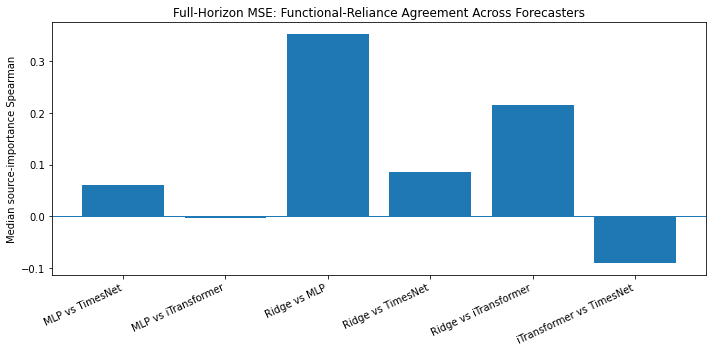

In [20]:
import matplotlib.pyplot as plt

plot = primary_forecaster.copy()

labels = (
    plot["forecaster_A"]
    +
    " vs "
    +
    plot["forecaster_B"]
)

x = np.arange(len(plot))

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.bar(
    x,
    plot["median_rho"],
)

ax.axhline(
    0.0,
    linewidth=1,
)

ax.set_xticks(x)

ax.set_xticklabels(
    labels,
    rotation=25,
    ha="right",
)

ax.set_ylabel(
    "Median source-importance Spearman"
)

ax.set_title(
    "Full-Horizon MSE: Functional-Reliance Agreement Across Forecasters"
)

plt.tight_layout()
plt.show()

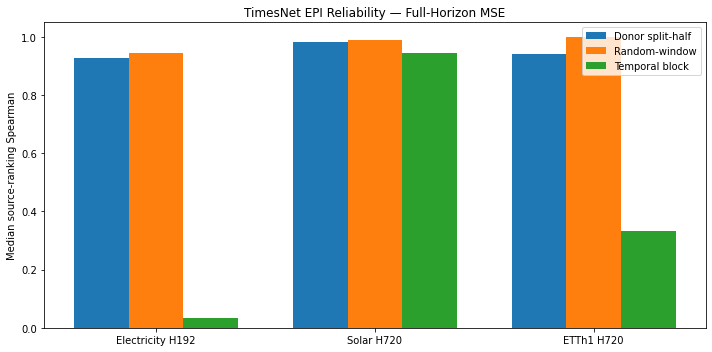

In [21]:
import matplotlib.pyplot as plt

labels = (
    reliability_overview["dataset"]
    +
    " H"
    +
    reliability_overview["pred_len"].astype(str)
)

x = np.arange(
    len(reliability_overview)
)

w = 0.25

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.bar(
    x - w,
    reliability_overview["donor_split_half_rho"],
    w,
    label="Donor split-half",
)

ax.bar(
    x,
    reliability_overview["random_window_split_half_rho"],
    w,
    label="Random-window",
)

ax.bar(
    x + w,
    reliability_overview["temporal_block_rho"],
    w,
    label="Temporal block",
)

ax.axhline(
    0.0,
    linewidth=1,
)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel(
    "Median source-ranking Spearman"
)

ax.set_title(
    "TimesNet EPI Reliability — Full-Horizon MSE"
)

ax.legend()

plt.tight_layout()
plt.show()

## 19. Conservative automatic interpretation

In [22]:
print("=" * 96)
print("TIMESNET STRONG-BACKBONE CONFIRMATORY TEST")
print("=" * 96)

print("\nPRIMARY METRIC: full-horizon MSE")

print(
    f"rho(P, TimesNet)            = {rho_P_timesnet:+.3f}"
)

print(
    f"rho(Ridge, TimesNet)        = {rho_ridge_timesnet:+.3f}"
)

print(
    f"rho(MLP, TimesNet)          = {rho_mlp_timesnet:+.3f}"
)

print(
    f"rho(iTransformer, TimesNet) = {rho_itr_timesnet:+.3f}"
)

reliable_conditions = (
    (
        reliability_overview[
            "donor_split_half_rho"
        ]
        >=
        0.60
    )
    &
    (
        reliability_overview[
            "random_window_split_half_rho"
        ]
        >=
        0.60
    )
)

print(
    "\nTimesNet reliable full-MSE conditions:",
    int(reliable_conditions.sum()),
    "/",
    len(reliable_conditions),
)

print("\nInterpretation:")

if (
    np.isfinite(rho_P_timesnet)
    and
    abs(rho_P_timesnet)
    <
    0.30
):
    print(
        "- Controlled predictive utility does not strongly align "
        "with TimesNet functional reliance."
    )
else:
    print(
        "- TimesNet shows non-negligible alignment with controlled "
        "predictive utility; report this rather than forcing a mismatch claim."
    )

if (
    np.isfinite(rho_itr_timesnet)
    and
    abs(rho_itr_timesnet)
    <
    0.30
):
    print(
        "- iTransformer and TimesNet rely on substantially different "
        "source rankings."
    )

    print(
        "- This supports forecaster-dependent functional source reliance."
    )

elif (
    np.isfinite(rho_itr_timesnet)
    and
    rho_itr_timesnet
    >=
    0.50
):
    print(
        "- iTransformer and TimesNet share a substantial neural "
        "source-reliance structure."
    )

    print(
        "- In this case, narrow the claim: strong neural forecasters "
        "may share source reliance that differs from controlled utility."
    )

else:
    print(
        "- Cross-architecture agreement is intermediate; report the "
        "measured degree of agreement without a binary claim."
    )

if reliable_conditions.sum() < 2:
    print(
        "- Reliability is limited in multiple conditions."
    )

    print(
        "- Do not use unstable pairwise TimesNet rankings as a strong "
        "generality claim; retain only reliable-condition evidence."
    )

print("\nWording constraint:")

print(
    "Do NOT write: predictive relevance is model-dependent."
)

print(
    "Use: functional source reliance is forecaster-dependent, "
    "or controlled source utility need not transfer to a separately "
    "trained neural forecaster."
)

print(
    "\nThis is a confirmatory experiment. Do not tune TimesNet, "
    "candidate pools, donors, or thresholds based on the observed outcome."
)

TIMESNET STRONG-BACKBONE CONFIRMATORY TEST

PRIMARY METRIC: full-horizon MSE
rho(P, TimesNet)            = +0.029
rho(Ridge, TimesNet)        = +0.086
rho(MLP, TimesNet)          = +0.060
rho(iTransformer, TimesNet) = -0.091

TimesNet reliable full-MSE conditions: 3 / 3

Interpretation:
- Controlled predictive utility does not strongly align with TimesNet functional reliance.
- iTransformer and TimesNet rely on substantially different source rankings.
- This supports forecaster-dependent functional source reliance.

Wording constraint:
Do NOT write: predictive relevance is model-dependent.
Use: functional source reliance is forecaster-dependent, or controlled source utility need not transfer to a separately trained neural forecaster.

This is a confirmatory experiment. Do not tune TimesNet, candidate pools, donors, or thresholds based on the observed outcome.


## Paper decision guide

This section implements robustness and reliability checks for predictive utility and functional reliance under the fixed protocols reported in the paper.
